# Car Price Prediction
#### School: Asian Institute of Technology
#### Program: Data Science & Artificial Intelligence(Aug 2026)
#### Name: Lin Htet Aung
#### Id: st127132



## Preview:

#### This notebook is all AI-generated. I won't upload this file as my assignment. This is just for preview and reference point.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Getting the cars data
df = pd.read_csv("../data/Cars.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


### Data Inspection

In [6]:
df.shape

(8128, 13)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [10]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [14]:
df.describe(include="str")

,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,8128,8128,8128,8128,8128,7907,7907,7913,7906
unique,2058,4,3,2,5,393,121,322,441
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
freq,129,4402,6766,7078,5289,225,1017,377,530


In [15]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(1202)

In [17]:
for column in df.select_dtypes(include="str").columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


name
name
Maruti Swift Dzire VDI                          129
Maruti Alto 800 LXI                              82
Maruti Alto LXi                                  71
BMW X4 M Sport X xDrive20d                       62
Maruti Swift VDI                                 61
                                               ... 
Maruti Celerio ZXI AMT BSIV                       1
Tata Bolt Revotron XM                             1
Tata Manza Aura (ABS) Safire BS IV                1
Tata Nexon 1.5 Revotorq XT                        1
Toyota Innova 2.5 GX (Diesel) 8 Seater BS IV      1
Name: count, Length: 2058, dtype: int64

fuel
fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

seller_type
seller_type
Individual          6766
Dealer              1126
Trustmark Dealer     236
Name: count, dtype: int64

transmission
transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64

owner
owner
First Owner             5289
Second Owner           

### Data Cleaning

In [18]:
df["owner"].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

In [19]:
df["fuel"].value_counts()

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

In [20]:
df = df[~df["fuel"].isin(["CNG", "LPG"])].copy()

In [21]:
df["mileage"] = (
    df["mileage"]
    .str.split()
    .str[0]
    .astype(float)
)

In [24]:
df["mileage"].head(10)

0     23.40
1     21.14
2     17.70
3     23.00
4     16.10
5     20.14
7     16.10
8     23.59
9     20.00
10    19.01
Name: mileage, dtype: float64

In [25]:
df["mileage"].dtype

dtype('float64')

In [26]:
df["engine"] = (
    df["engine"]
    .str.split()
    .str[0]
    .astype(float)
)

In [27]:
df["engine"].head(10)

0     1248.0
1     1498.0
2     1497.0
3     1396.0
4     1298.0
5     1197.0
7      796.0
8     1364.0
9     1399.0
10    1461.0
Name: engine, dtype: float64

In [28]:
df["engine"].dtype

dtype('float64')

In [29]:
df["max_power"].unique()

<StringArray>
[    '74 bhp', '103.52 bhp',     '78 bhp',     '90 bhp',   '88.2 bhp',
  '81.86 bhp',     '37 bhp',   '67.1 bhp',   '68.1 bhp', '108.45 bhp',
 ...
   '82.5 bhp',  '141.1 bhp',  '197.2 bhp',    '161 bhp',    '194 bhp',
  '122.4 bhp', '134.10 bhp',    '134 bhp',    '203 bhp',  '135.1 bhp']
Length: 310, dtype: str

In [34]:
mp = df["max_power"].unique()
print(type(mp[0]))
for i in mp:
    try:
        if "bhp" in i:
            continue
        else:
            print(i)
    except TypeError:
        # Handles np.nan or numeric values safely
        print(f"Skipped non-string value: {i} ({type(i).__name__})")

<class 'str'>
Skipped non-string value: nan (float)
0


In [45]:
# 1. Force the entire column to string type, lowercased, and stripped of extra spaces
df["max_power"] = df["max_power"].astype(str).str.lower().str.strip()

# 2. Replace textual 'nan', 'null', or lone '0' values with a proper pandas NaN
invalid_values = ["nan", "null", "0", "0.0", "bhp"]
df["max_power"] = df["max_power"].replace(invalid_values, np.nan)

# 3. Extract the numeric values (digits and decimals)
df["max_power"] = df["max_power"].str.extract(r"([\d\.]+)").astype(float)

# 4. View your perfectly cleaned, unique numeric values
print(df["max_power"].unique())

[ 74.    103.52   78.     90.     88.2    81.86   37.     67.1    68.1
 108.45   60.     73.9       nan  67.     82.     88.5    46.3    88.73
  64.1    98.6    88.8    83.81   83.1    47.3    73.8    34.2    35.
  81.83  121.3   138.03  160.77  117.3   116.3    83.14   67.05  168.5
 100.    120.7    98.63  175.56  103.25  171.5   100.6   174.33  187.74
 170.     78.9    88.76   86.8   108.495 108.62   93.7   103.6    98.59
 189.     67.04   68.05   82.85   81.8    73.    120.     94.68  160.
  65.    155.     69.01  126.32  138.1    83.8   126.2    98.96   62.1
  86.7   188.    214.56  177.    280.    148.31  254.79  190.    177.46
 204.    141.    117.6   241.4   282.    150.    147.5   108.5   103.5
 183.    181.04  157.7   164.7    91.1   400.     68.     75.     85.8
  87.2    53.    118.    103.2    83.     84.    147.94   74.02   53.3
  80.     88.7    97.7   121.36  162.    140.     94.    100.57   82.9
  83.11   70.    153.86  121.    126.3    73.97  171.     69.     99.6
 102

In [35]:
df["brand"] = df["name"].str.split().str[0]

In [36]:
df["brand"].value_counts()

brand
Maruti           2378
Hyundai          1393
Mahindra          772
Tata              733
Toyota            488
Honda             467
Ford              397
Renault           228
Chevrolet         228
Volkswagen        186
BMW               120
Skoda             105
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               47
Audi               40
Lexus              34
Jeep               31
Mitsubishi         14
Land                6
Force               6
Isuzu               5
Kia                 4
Ambassador          4
MG                  3
Daewoo              3
Ashok               1
Opel                1
Peugeot             1
Name: count, dtype: int64

In [37]:
df = df.drop(columns=["name"])

In [38]:
df = df.drop(columns=["torque"])

In [39]:
df = df[df["owner"] != "Test Drive Car"].copy()

In [40]:
owner_mapping = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4
}

df["owner"] = df["owner"].map(owner_mapping)

In [41]:
df["owner"].value_counts()

owner
1    5238
2    2073
3     547
4     170
Name: count, dtype: int64

In [48]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0,Maruti
1,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0,Skoda
2,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0,Honda
3,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0,Hyundai
4,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0,Maruti


In [49]:
df.info()

<class 'pandas.DataFrame'>
Index: 8028 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           8028 non-null   int64  
 1   selling_price  8028 non-null   int64  
 2   km_driven      8028 non-null   int64  
 3   fuel           8028 non-null   str    
 4   seller_type    8028 non-null   str    
 5   transmission   8028 non-null   str    
 6   owner          8028 non-null   int64  
 7   mileage        7814 non-null   float64
 8   engine         7814 non-null   float64
 9   max_power      7814 non-null   float64
 10  seats          7814 non-null   float64
 11  brand          8028 non-null   object 
dtypes: float64(4), int64(4), object(1), str(3)
memory usage: 815.3+ KB


In [50]:
df.isnull().sum()

year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          214
engine           214
max_power        214
seats            214
brand              0
dtype: int64

### EDA


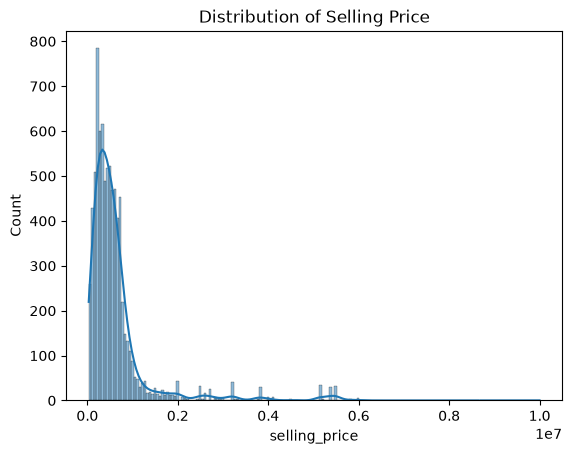

In [51]:
sns.histplot(df["selling_price"], kde=True)
plt.title("Distribution of Selling Price")
plt.show()

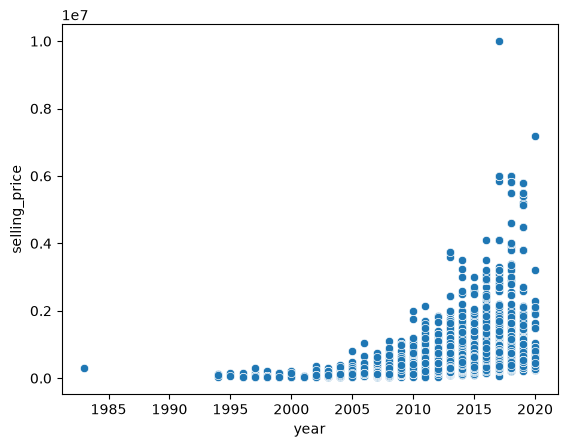

In [52]:
sns.scatterplot(data=df, x="year", y="selling_price")
plt.show()

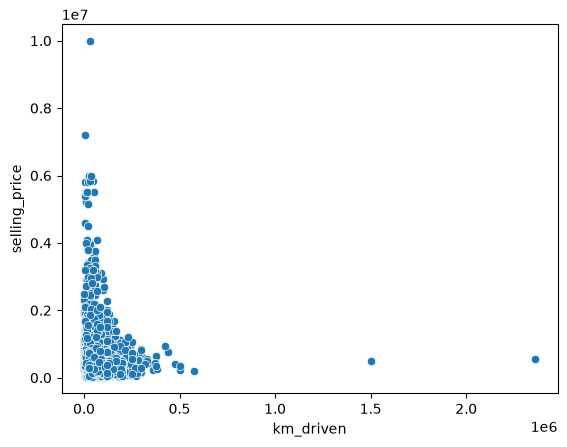

In [53]:
sns.scatterplot(data=df,x="km_driven", y="selling_price")
plt.show()

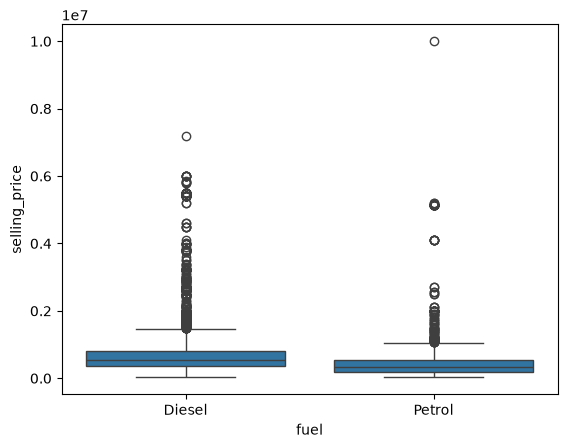

In [54]:
sns.boxplot(data=df, x="fuel", y="selling_price")
plt.show()

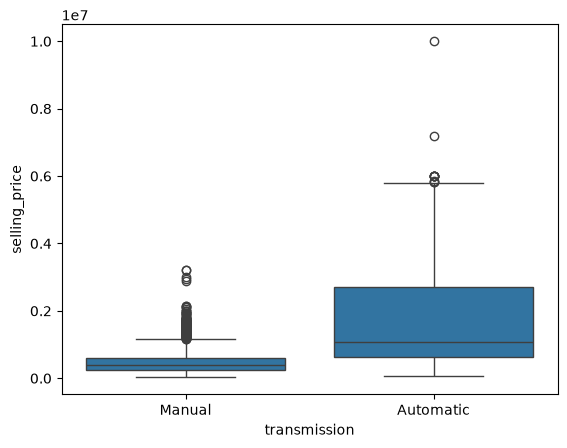

In [55]:
sns.boxplot(data=df, x="transmission", y="selling_price")
plt.show()

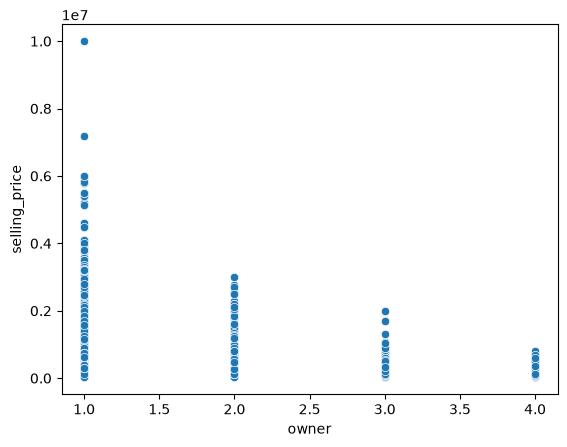

In [57]:
sns.scatterplot(data=df, x="owner", y="selling_price")
plt.show()

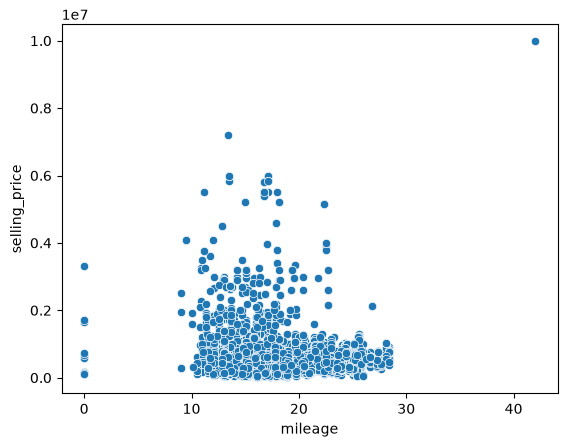

In [59]:
sns.scatterplot(data=df, x="mileage", y="selling_price")
plt.show()

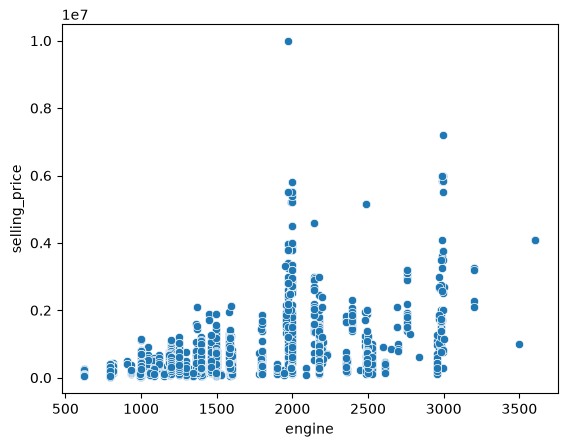

In [61]:
sns.scatterplot(data=df, x="engine", y="selling_price")
plt.show()

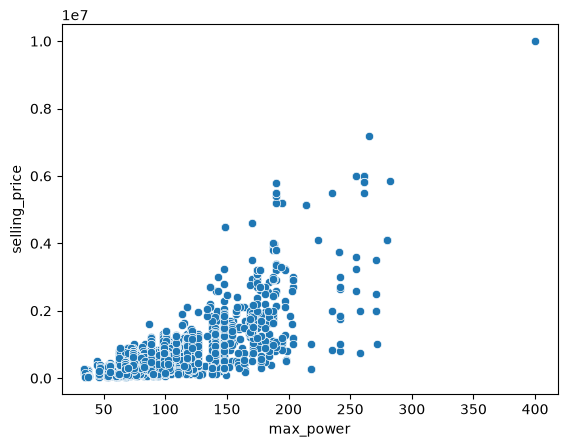

In [62]:
sns.scatterplot(data=df, x="max_power", y="selling_price")
plt.show()

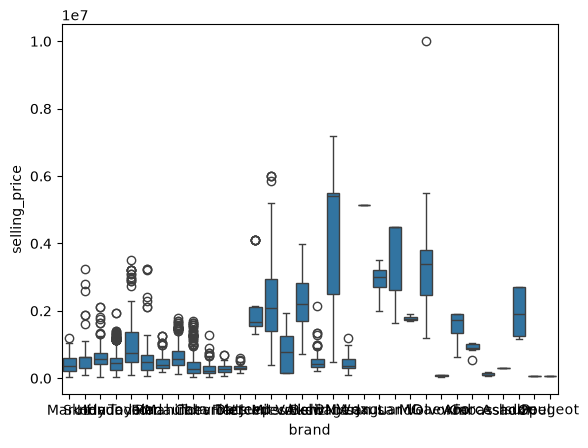

In [63]:
sns.boxplot(data=df, x="brand", y="selling_price")
plt.show()

### Train/Test Split

In [64]:
X = df.drop(columns=["selling_price"])
y = df["selling_price"]

In [65]:
y = np.log(df["selling_price"])

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [68]:
numeric_features = [
    "year",
    "km_driven",
    "owner",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

categorical_features = [
    "fuel",
    "seller_type",
    "transmission",
    "brand"
]

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor



In [70]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [85]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

In [86]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [87]:
baseline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="median"))
    ]
)

In [88]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.model_selection import (
    KFold,
    cross_validate
)
from sklearn.inspection import permutation_importance

import joblib

RANDOM_STATE = 42

In [89]:
models = {
    "Dummy": DummyRegressor(strategy="median"),
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    )
}

In [90]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [91]:
results = []

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        },
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "CV MAE": -scores["test_mae"].mean(),
        "CV RMSE": -scores["test_rmse"].mean(),
        "CV R²": scores["test_r2"].mean()
    })

In [92]:
cv_results = pd.DataFrame(results)
cv_results.sort_values("CV RMSE")

,Model,CV MAE,CV RMSE,CV R²
4,Random Forest,0.143343,0.211164,0.936130
5,Gradient Boosting,0.165919,0.225902,0.926934
2,Ridge,0.190903,0.257571,0.905039
1,Linear Regression,0.190688,0.257708,0.904940
3,Decision Tree,0.180765,0.277966,0.889381
0,Dummy,0.630306,0.837667,-0.003753


In [93]:
best_model = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", best_model)
    ]
)

final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['year','km_driven','fuel',...,'max_power','seats','brand']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatena

In [96]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [94]:
pred_log = final_pipeline.predict(X_test)

In [95]:
pred_price = np.exp(pred_log)
actual_price = np.exp(y_test)

In [97]:
mae = mean_absolute_error(
    actual_price,
    pred_price
)

rmse = np.sqrt(
    mean_squared_error(
        actual_price,
        pred_price
    )
)

r2 = r2_score(
    actual_price,
    pred_price
)

print(f"Test MAE : {mae:,.2f}")
print(f"Test RMSE: {rmse:,.2f}")
print(f"Test R²  : {r2:.4f}")

Test MAE : 67,746.05
Test RMSE: 202,660.11
Test R²  : 0.9470


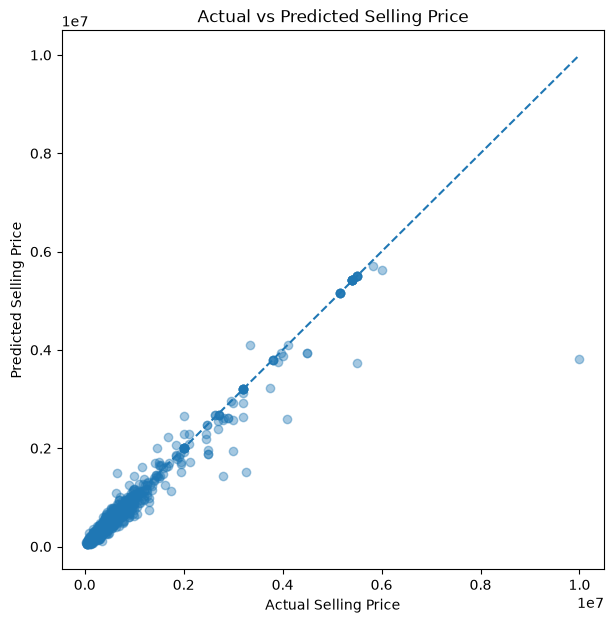

In [98]:
plt.figure(figsize=(7, 7))

plt.scatter(
    actual_price,
    pred_price,
    alpha=0.4
)

minimum = min(
    actual_price.min(),
    pred_price.min()
)

maximum = max(
    actual_price.max(),
    pred_price.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.show()

In [99]:
prediction_df = pd.DataFrame({
    "actual": actual_price,
    "predicted": pred_price
})

prediction_df["absolute_error"] = (
    prediction_df["actual"]
    - prediction_df["predicted"]
).abs()

prediction_df["percentage_error"] = (
    prediction_df["absolute_error"]
    / prediction_df["actual"]
) * 100

In [100]:
prediction_df.sort_values(
    "absolute_error",
    ascending=False
).head(20)

,actual,predicted,absolute_error,percentage_error
170,10000000.0,3.811333e+06,6.188667e+06,61.886673
7516,5500000.0,3.725345e+06,1.774655e+06,32.266450
5511,3251000.0,1.511770e+06,1.739230e+06,53.498316
3248,4090000.0,2.597392e+06,1.492608e+06,36.494087
7922,2800000.0,1.434625e+06,1.365375e+06,48.763410
7077,3000000.0,1.947271e+06,1.052729e+06,35.090951
488,643000.0,1.498041e+06,8.550409e+05,132.976810
1979,3350000.0,4.098092e+06,7.480922e+05,22.331110
5985,2000000.0,2.664198e+06,6.641982e+05,33.209910
4019,1750000.0,1.125706e+06,6.242939e+05,35.673936


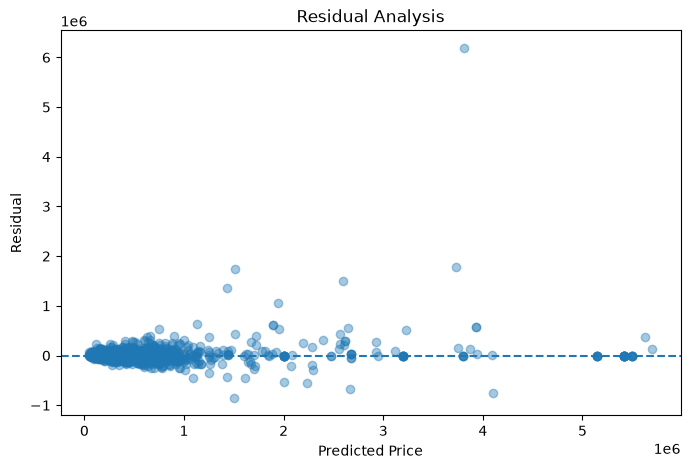

In [101]:
residuals = actual_price - pred_price

plt.figure(figsize=(8, 5))

plt.scatter(
    pred_price,
    residuals,
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Analysis")

plt.show()

In [102]:
importance = permutation_importance(
    final_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="r2"
)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance.importances_mean
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,year,0.554454
8,max_power,0.499434
7,engine,0.067906
10,brand,0.035658
6,mileage,0.013480
1,km_driven,0.013067
2,fuel,0.008037
9,seats,0.002658
5,owner,0.002109
4,transmission,0.001778


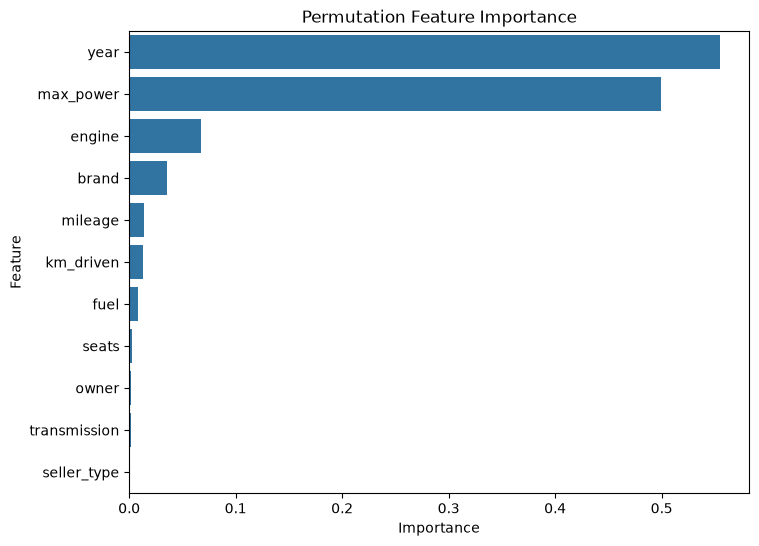

In [103]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Permutation Feature Importance")
plt.show()

In [104]:
new_car = pd.DataFrame([{
    "year": 2018,
    "km_driven": 50000,
    "fuel": "Petrol",
    "seller_type": "Individual",
    "transmission": "Manual",
    "owner": 1,
    "mileage": 20.0,
    "engine": 1200.0,
    "max_power": 82.0,
    "seats": 5.0,
    "brand": "Maruti"
}])

In [105]:
pred_log = final_pipeline.predict(new_car)

predicted_price = np.exp(pred_log)[0]

print(f"Predicted selling price: {predicted_price:,.2f}")

Predicted selling price: 503,838.53


In [106]:
new_car_missing = pd.DataFrame([{
    "year": 2018,
    "km_driven": 50000,
    "fuel": "Petrol",
    "seller_type": "Individual",
    "transmission": "Manual",
    "owner": 1,
    "mileage": np.nan,
    "engine": 1200.0,
    "max_power": np.nan,
    "seats": 5.0,
    "brand": "Maruti"
}])

prediction = np.exp(
    final_pipeline.predict(new_car_missing)
)[0]

print(f"Predicted price: {prediction:,.2f}")

Predicted price: 502,436.33


In [108]:
import joblib

In [109]:
joblib.dump(
    final_pipeline,
    "../models/car_price_model.joblib"
)

['../models/car_price_model.joblib']

In [110]:
loaded_model = joblib.load(
    "../models/car_price_model.joblib"
)

loaded_prediction = np.exp(
    loaded_model.predict(new_car)
)[0]

print(loaded_prediction)

503838.5316766751
